In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/CloudWatch_Traffic_Web_Attack.csv')

df.head()

,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types
0,5602,12990,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,147.161.161.82,AE,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
1,30912,18186,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.33.6,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
2,28506,13468,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.212.255,CA,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
3,30546,14278,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,136.226.64.114,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule
4,6526,13892,2024-04-25T23:00:00Z,2024-04-25T23:10:00Z,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25T23:00:00Z,waf_rule


In [2]:
df.shape

(282, 16)

In [3]:
df.columns

Index(['bytes_in', 'bytes_out', 'creation_time', 'end_time', 'src_ip',
       'src_ip_country_code', 'protocol', 'response.code', 'dst_port',
       'dst_ip', 'rule_names', 'observation_name', 'source.meta',
       'source.name', 'time', 'detection_types'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   bytes_in             282 non-null    int64 
 1   bytes_out            282 non-null    int64 
 2   creation_time        282 non-null    object
 3   end_time             282 non-null    object
 4   src_ip               282 non-null    object
 5   src_ip_country_code  282 non-null    object
 6   protocol             282 non-null    object
 7   response.code        282 non-null    int64 
 8   dst_port             282 non-null    int64 
 9   dst_ip               282 non-null    object
 10  rule_names           282 non-null    object
 11  observation_name     282 non-null    object
 12  source.meta          282 non-null    object
 13  source.name          282 non-null    object
 14  time                 282 non-null    object
 15  detection_types      282 non-null    object
dtypes: int64

In [5]:
df.isna().sum()

,0
bytes_in,0
bytes_out,0
creation_time,0
end_time,0
src_ip,0
src_ip_country_code,0
protocol,0
response.code,0
dst_port,0
dst_ip,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['creation_time'] = pd.to_datetime(df['creation_time'])
df['end_time'] = pd.to_datetime(df['end_time'])
df['time'] = pd.to_datetime(df['time'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   bytes_in             282 non-null    int64              
 1   bytes_out            282 non-null    int64              
 2   creation_time        282 non-null    datetime64[ns, UTC]
 3   end_time             282 non-null    datetime64[ns, UTC]
 4   src_ip               282 non-null    object             
 5   src_ip_country_code  282 non-null    object             
 6   protocol             282 non-null    object             
 7   response.code        282 non-null    int64              
 8   dst_port             282 non-null    int64              
 9   dst_ip               282 non-null    object             
 10  rule_names           282 non-null    object             
 11  observation_name     282 non-null    object             
 12  source.meta          2

In [8]:
df['session_duration'] = (df['end_time'] - df['creation_time']).dt.total_seconds()

df[['creation_time' , 'end_time' , 'session_duration']].head()

,creation_time,end_time,session_duration
0,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,600.0
1,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,600.0
2,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,600.0
3,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,600.0
4,2024-04-25 23:00:00+00:00,2024-04-25 23:10:00+00:00,600.0


In [9]:
features = df[['bytes_in' , 'bytes_out' , 'session_duration']]

features.head()

,bytes_in,bytes_out,session_duration
0,5602,12990,600.0
1,30912,18186,600.0
2,28506,13468,600.0
3,30546,14278,600.0
4,6526,13892,600.0


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features


array([[-2.88218983e-01, -2.81222716e-01,  0.00000000e+00],
       [-2.82108333e-01, -2.60804248e-01,  0.00000000e+00],
       [-2.82689219e-01, -2.79344343e-01,  0.00000000e+00],
       [-2.82196697e-01, -2.76161325e-01,  0.00000000e+00],
       [-2.87995900e-01, -2.77678171e-01,  0.00000000e+00],
       [-2.88628452e-01, -3.18562264e-01,  0.00000000e+00],
       [-2.85286547e-01, -2.17491630e-01,  0.00000000e+00],
       [ 8.61557498e-01,  8.13303092e-01,  0.00000000e+00],
       [-2.87027273e-01, -2.71304276e-01,  0.00000000e+00],
       [-2.87240217e-01, -3.07197712e-01,  0.00000000e+00],
       [-2.75759630e-01, -2.03085528e-01,  0.00000000e+00],
       [-2.85186594e-01, -2.12445957e-01,  0.00000000e+00],
       [-2.82797863e-01, -3.13280813e-01,  0.00000000e+00],
       [-2.71765374e-01, -2.57904165e-01,  0.00000000e+00],
       [-2.88586443e-01, -2.87934561e-01,  0.00000000e+00],
       [ 1.85785218e-01, -1.79904514e-01,  0.00000000e+00],
       [-2.87891601e-01, -2.81757149e-01

In [11]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.05, random_state=42)

df['anomaly_flag'] = iso_forest.fit_predict(scaled_features)

df['anomaly_flag'].value_counts()

,count
anomaly_flag,
1,267
-1,15


In [12]:
df['anomaly_label'] = df['anomaly_flag'].apply(lambda x: 'Suspicious' if x == -1 else 'Normal')

df[['bytes_in', 'bytes_out', 'session_duration', 'anomaly_label']].head()


,bytes_in,bytes_out,session_duration,anomaly_label
0,5602,12990,600.0,Normal
1,30912,18186,600.0,Normal
2,28506,13468,600.0,Normal
3,30546,14278,600.0,Normal
4,6526,13892,600.0,Normal


In [13]:
df['anomaly_label'].value_counts()


,count
anomaly_label,
Normal,267
Suspicious,15


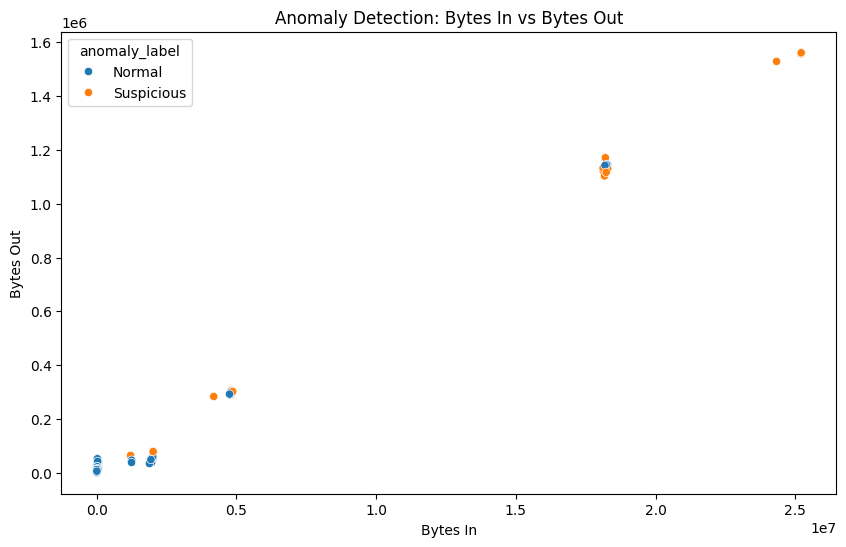

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df['bytes_in'],
    y=df['bytes_out'],
    hue=df['anomaly_label']
)
plt.title("Anomaly Detection: Bytes In vs Bytes Out")
plt.xlabel("Bytes In")
plt.ylabel("Bytes Out")
plt.show()


The scatter plot between incoming and outgoing traffic shows that suspicious sessions significantly deviate from normal traffic clusters, validating the anomaly detection model’s effectiveness.

In [15]:
suspicious_country_counts = (
    df[df['anomaly_label'] == 'Suspicious']['src_ip_country_code']
    .value_counts()
)

suspicious_country_counts


,count
src_ip_country_code,
US,12
NL,3


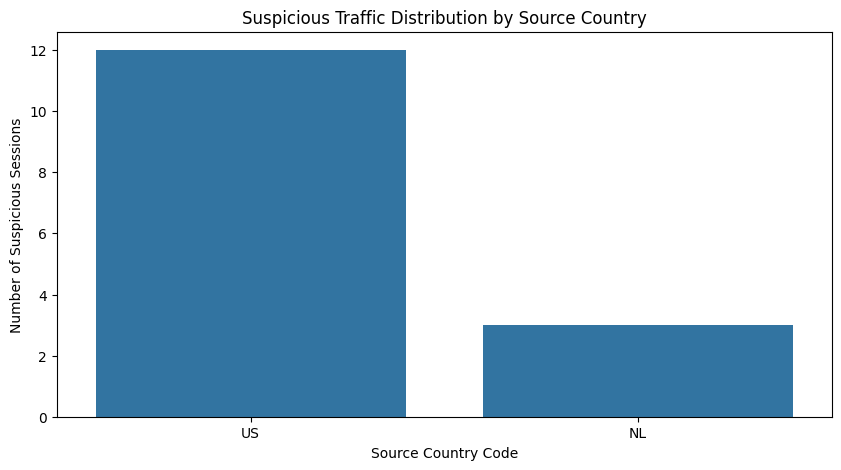

In [16]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=suspicious_country_counts.index,
    y=suspicious_country_counts.values
)
plt.title("Suspicious Traffic Distribution by Source Country")
plt.xlabel("Source Country Code")
plt.ylabel("Number of Suspicious Sessions")
plt.show()


In [17]:
pd.crosstab(
    df['anomaly_label'],
    df['detection_types']
)


detection_types,waf_rule
anomaly_label,
Normal,267
Suspicious,15


In [18]:
suspicious_df = df[df['anomaly_label'] == 'Suspicious']

suspicious_df.head()


,bytes_in,bytes_out,creation_time,end_time,src_ip,src_ip_country_code,protocol,response.code,dst_port,dst_ip,rule_names,observation_name,source.meta,source.name,time,detection_types,session_duration,anomaly_flag,anomaly_label
36,4190330,283456,2024-04-25 23:30:00+00:00,2024-04-25 23:40:00+00:00,155.91.45.242,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25 23:30:00+00:00,waf_rule,600.0,-1,Suspicious
43,2015975,79990,2024-04-25 23:40:00+00:00,2024-04-25 23:50:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-25 23:40:00+00:00,waf_rule,600.0,-1,Suspicious
87,1215594,64362,2024-04-26 00:30:00+00:00,2024-04-26 00:40:00+00:00,165.225.240.79,NL,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 00:30:00+00:00,waf_rule,600.0,-1,Suspicious
116,4827283,306181,2024-04-26 01:00:00+00:00,2024-04-26 01:10:00+00:00,155.91.45.242,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 01:00:00+00:00,waf_rule,600.0,-1,Suspicious
153,4869181,301752,2024-04-26 01:40:00+00:00,2024-04-26 01:50:00+00:00,155.91.45.242,US,HTTPS,200,443,10.138.69.97,Suspicious Web Traffic,Adversary Infrastructure Interaction,AWS_VPC_Flow,prod_webserver,2024-04-26 01:40:00+00:00,waf_rule,600.0,-1,Suspicious


In [19]:
suspicious_ip_counts = suspicious_df['src_ip'].value_counts()

suspicious_ip_counts


,count
src_ip,
155.91.45.242,12
165.225.240.79,3


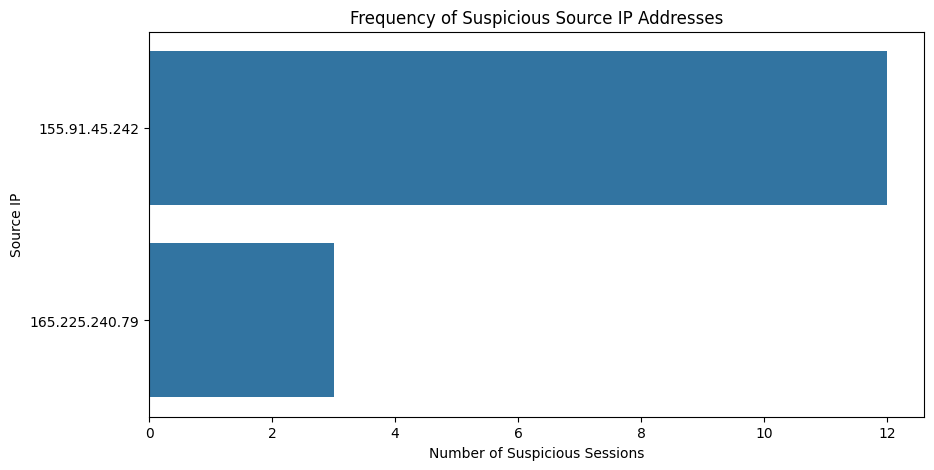

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=suspicious_ip_counts.values,
    y=suspicious_ip_counts.index
)
plt.title("Frequency of Suspicious Source IP Addresses")
plt.xlabel("Number of Suspicious Sessions")
plt.ylabel("Source IP")
plt.show()


In [21]:
suspicious_df['hour'] = suspicious_df['creation_time'].dt.hour

suspicious_df['hour'].value_counts().sort_index()


/tmp/ipython-input-2470779914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  suspicious_df['hour'] = suspicious_df['creation_time'].dt.hour


,count
hour,
0,1
1,2
8,4
9,6
23,2


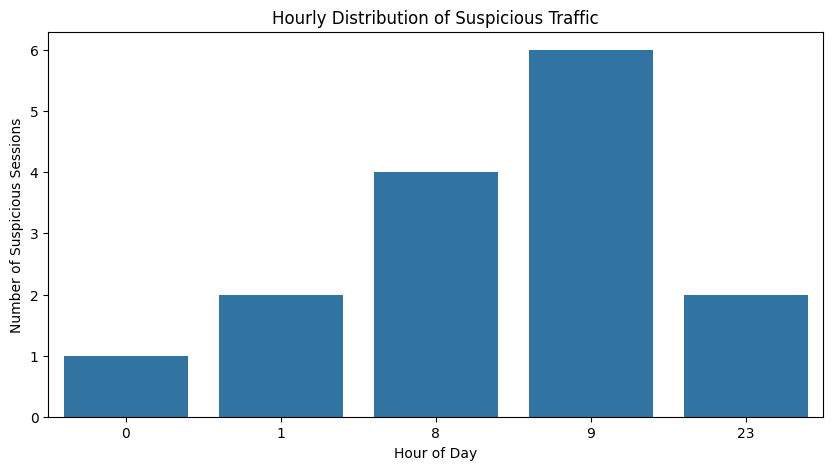

In [22]:
hourly_counts = suspicious_df['hour'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(
    x=hourly_counts.index,
    y=hourly_counts.values
)
plt.title("Hourly Distribution of Suspicious Traffic")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Suspicious Sessions")
plt.show()


In [23]:
total_sessions = len(df)
normal_sessions = (df['anomaly_label'] == 'Normal').sum()
suspicious_sessions = (df['anomaly_label'] == 'Suspicious').sum()

summary_df = pd.DataFrame({
    'Metric': ['Total Sessions', 'Normal Sessions', 'Suspicious Sessions'],
    'Count': [total_sessions, normal_sessions, suspicious_sessions]
})

summary_df


,Metric,Count
0,Total Sessions,282
1,Normal Sessions,267
2,Suspicious Sessions,15



This project analyzed web traffic data collected via AWS CloudWatch to identify suspicious web interactions.
Using an unsupervised anomaly detection approach with Isolation Forest, behavioral patterns were learned from
traffic volume and session duration features. The model successfully identified a small subset of sessions
as anomalous, aligning with realistic cybersecurity threat distributions. Further analysis revealed that
suspicious activity originated from specific source IPs, countries, and time periods, indicating possible
automated or adversarial behavior. This approach demonstrates how behavior-based machine learning can
complement rule-based security systems for effective threat detection.

